In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data.csv')
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [ ]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
residual = y_test-y_pred

# Linear Relationship

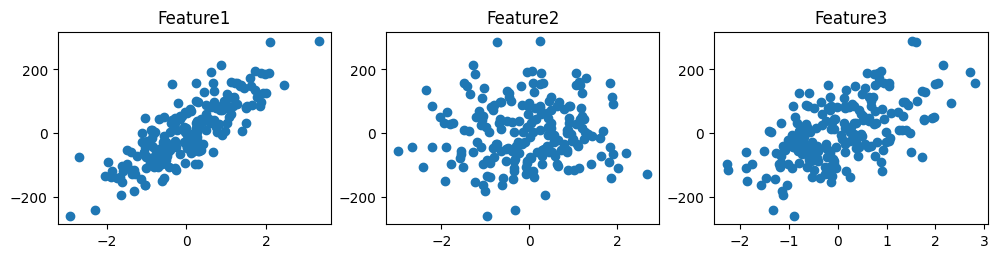

In [ ]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,2.5))

ax1.scatter(df['feature1'],df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'],df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'],df['target'])
ax3.set_title("Feature3")
plt.show()

# Multicolinearity

In [ ]:
#Multicolinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif =[]
for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train,i))

In [ ]:
pd.DataFrame({'vif':vif},index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.00195,1.011273,1.011211


<Axes: >

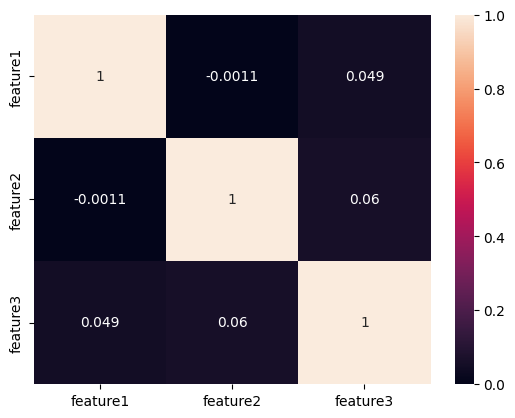

In [ ]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

# Normal Residual

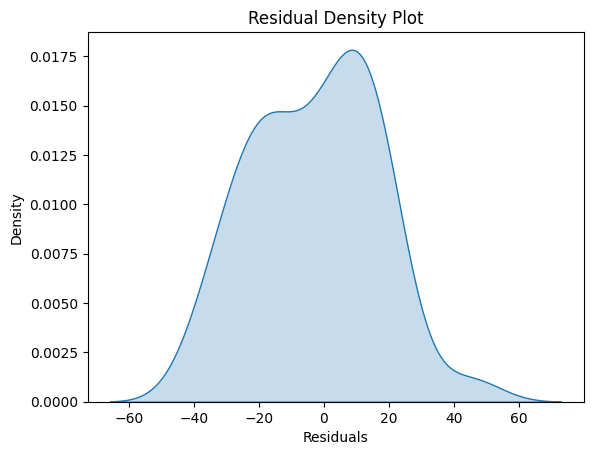

In [ ]:
sns.kdeplot(residual, fill=True)

plt.xlabel("Residuals")
plt.title("Residual Density Plot")
plt.show()

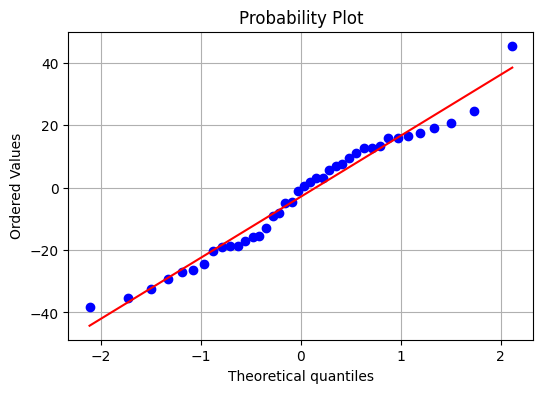

In [ ]:
#QQPlot
import scipy as sp

fig,ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual,plot=ax,fit=True)
plt.grid(True)
plt.show()

# Homo-scedasticity

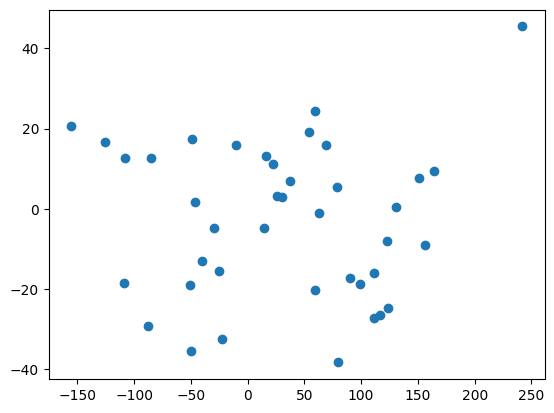

In [ ]:
#Homo-scedasticity
plt.scatter(y_pred,residual)

# No Autocorrelation of Error

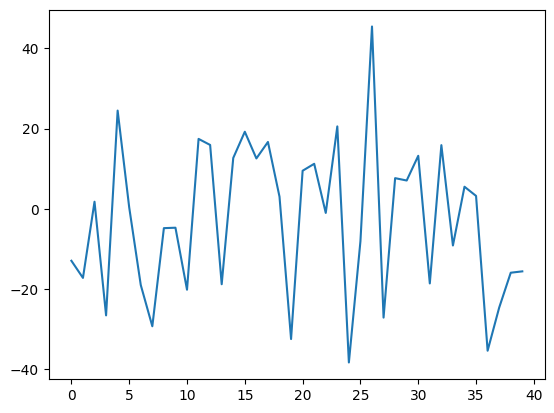

In [ ]:
plt.plot(residual)